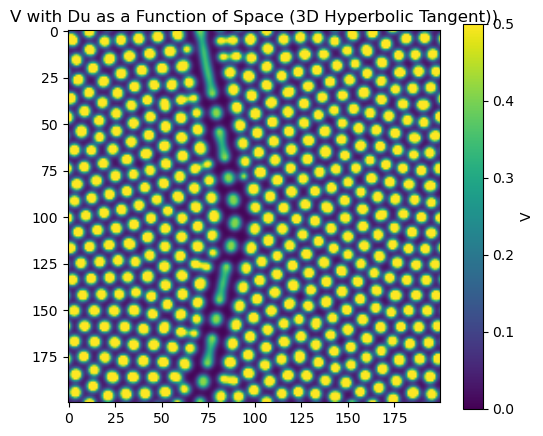

In [39]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

def first_derivative(M, axis, dx):
    firstD = (np.roll(M, 1, axis) - np.roll(M, -1, axis)) / (2 * dx)
    return firstD
        
def combined_derivative(D, Concentration, dx):
    dD_dx = first_derivative(D, 0, dx)
    dU_dx = first_derivative(Concentration, 0, dx)
    dD_dy = first_derivative(D, 1, dx)
    dU_dy = first_derivative(Concentration, 1, dx)
    return dD_dx * dU_dx + dD_dy * dU_dy

def laplacian(Z, dx):
    d2Z_dx2 = np.roll(Z, 1, 0) - 2 * Z + np.roll(Z, -1, 0)
    d2Z_dy2 = np.roll(Z, 1, 1) - 2 * Z + np.roll(Z, -1, 1) 

    derivative = (d2Z_dx2 + d2Z_dy2)/(dx * dx) 
    
    return derivative

def solver(U, V, Du, Dv, F, k, dx, dt):

    # print(np.mean(U), np.mean(V))
    Lu = laplacian(U, dx)
    Lv = laplacian(V, dx)

    uvv = U * V * V

    U += (Du * Lu + combined_derivative(Du,U,dx) - uvv + F * (1 - U)) * dt
    V += (Dv * Lv + combined_derivative(Dv,V,dx) + uvv - (F+k) * V) * dt

    return U, V

''' PARAMETERS '''
F, k =  0.046, 0.064 #(Stripes) #0.028, 0.064 (Dots) #0.010, 0.046 (Dynamic) #0.037, 0.06 (Standard)
N = 200
L = 200
dx = L / N
n_steps = 400 #10000 #Using 300 for video. 
scale = 0.16
dt = 0.2

x = np.linspace(0,L,N,endpoint=False)
y = np.linspace(0,L,N,endpoint=False)
X,Y = np.meshgrid(x,y)

''' DIFFUSION CONSTANT '''
Du = np.zeros((N,N))
Dv = (scale/2) * np.ones_like(Du)  # Dv = 0.08 For now I have placed Dv = Du/2 because that is the ratio we have been using so far. I still don't know why works, but it does.

transition = 10 #this will control how sharp the chnage in concentration will be at the boundry p1 and p2
height = 5 
slope = 5 #slope - rotates about a point

''' NEW LOGIC '''
# X_0 = 37 #shift on x-axis
# k = 100 #width control - in order to change this you must graph on desmos first and then see how to change l and u repsectivly
# u = 2 #Another way to control width - just changes in one direction tho - better to change l and shift. u should not be too big or the graph will not be on this coordinate size. 

# z1 = (Y + slope * (X - X_0) - k) / transition
# z2 = - (Y + slope * (X - X_0) - u * k) / transition
# z3 = - (Y - slope * (X - X_0) - k) / transition
# z4 = (Y - slope * (X - X_0) - u * k) / transition

''' OLD LOGIC '''
width = 5. #normally 2
t = width-2

z1 = (Y + slope * X - width*N//2) / transition
z2 = -(Y + slope * X - 3 * N) / transition
z3 = (Y - slope * X + t * N//2) / transition
z4 = -(Y - slope * X + 2*N) / transition 


''' FUNCTIONS '''
tanh_bottom = ((height -1)/2) * (-1 * (np.tanh(z1) + np.tanh(z2)) + 2) + 1
tanh_top =  ((height -1)/2) * (np.tanh(z3) +  np.tanh(z4) + 2) + 1

Du[0:N//2, :] = scale * tanh_top[0:N//2, :]
Du[N//2:, :] = np.flip(Du[0:N//2, :], axis=0)

''' SET INITIAL CONDITIONS '''

U = np.ones((N,N))
V = np.zeros((N,N))

r = 20
U[N//2 - r:N//2+r, N//2 - r: N//2 + r] = 0.75 #orginally was 0.50
V[N//2 - r:N//2+r, N//2 - r: N//2 + r] = 0.50 #orginally was 0.25
U += 0.05 * np.random.rand(N,N)
V += 0.05 * np.random.rand(N,N)

''' PLOT INITIAL TIMESTEP '''

# fig, ax = plt.subplots(figsize=(8,6)) #regular sizing in a cube
# im = ax.imshow(Du, cmap='inferno', interpolation='bilinear', vmin=0, vmax=1)
# plt.axis('on')

# cbar = fig.colorbar(im, ax=ax)
# cbar.set_label('[V]')

# plt.plot(Du[N//2,:])

''' SOLVE FOR CONCENTRATIONS '''

total_V_concentration = np.zeros(n_steps)
total_time = np.zeros(n_steps)

for i in range(n_steps):
    for _ in range(100):
        U, V = solver(U, V, Du, Dv, F, k, dx, dt)
    
    total_time[i] = i * dt 
    total_V_concentration[i] = np.mean(V)

# ''' PLOT FINAL TIMESTEP '''

plt.figure(figsize=(6,5))
plt.imshow(V, cmap='viridis', interpolation='bilinear', vmin=0, vmax=0.5)
plt.title('V with Du as a Function of Space (3D Hyperbolic Tangent))')
plt.colorbar(label='V')
plt.show()

# def update(frame, U, V, Du, Dv, F, k, dx, dt):
#     for _ in range(100):
#         U, V = solver(U, V, Du, Dv, F, k, dx, dt)
    
#     total_time[frame] = frame * dt * 100
#     total_V_concentration[frame] = np.mean(V)

#     im.set_array(V)
#     return [im] 

# im.set_array(V)
# matplotlib.rcParams['animation.embed_limit'] = 1000

# ani = animation.FuncAnimation(fig, update, frames=n_steps, interval = 0.1, blit=False, fargs=(U, V, Du, Dv, F, k, dx, dt))
# plt.show()
# HTML(ani.to_jshtml())

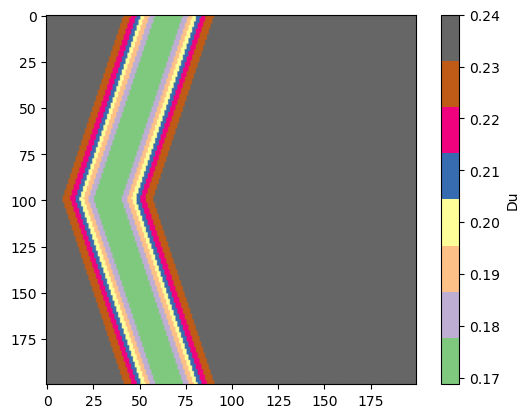

In [9]:
###########Testing DU if it is correct graph. 

%matplotlib inline

from IPython.display import HTML
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation

F, k =  0.046, 0.064 #(Stripes) #0.028, 0.064 (Dots) #0.010, 0.046 (Dynamic) #0.037, 0.06 (Standard)
N = 200
L = 200
dx = L / N

dy = dx
n_steps = 400 #10000 #Using 300 for video. 
sharpness = 30 #this will control how sharp the chnage in concentration will be at the boundry p1 and p2
scale = 0.16


Du = np.zeros((N,N))

x = np.linspace(0,L,N)
y = np.linspace(0,L,N)

X,Y = np.meshgrid(x,y)


##################FUNCTION START

s=3 #slope - rotates about a point
o = 33 #shift on x-axis
l = 0 # Some shift in a weird direction - keep constant
k = 57 #width control - in order to change this you must graph on desmos first and then see how to change l and u repsectivly
u = 2.5 #Another way to control width - just changes in one direction tho - better to change l and shift. u should not be too big or the graph will not be on this coordinate size. 
maxDu = 1.5 #maximum Du

cat = (s * (X-o) + (Y-l) - k)/sharpness
brill = -1 * (s * (X-o) + (Y - l) - u * k)/sharpness
silverman = (-s * (X-o) + (Y-l) - k)/sharpness
brooks = -1 * (-s * (X-o) + (Y-l) - u * k)/ sharpness

tanh_top_new = ((maxDu - 1)/2) * (-np.tanh(cat)-np.tanh(brill)+2) + 1
tanh_bottom_new = ((maxDu -1)/2 * (-np.tanh(silverman)-np.tanh(brooks)+2))+1

################FUNCTION DONE

Du[0:N//2, :] = scale * tanh_top_new[0:N//2, :]
Du[N//2:N, :] = scale * tanh_bottom_new[N//2:N, :]


plt.imshow(Du, cmap='Accent')
plt.colorbar(label='Du')
plt.show()

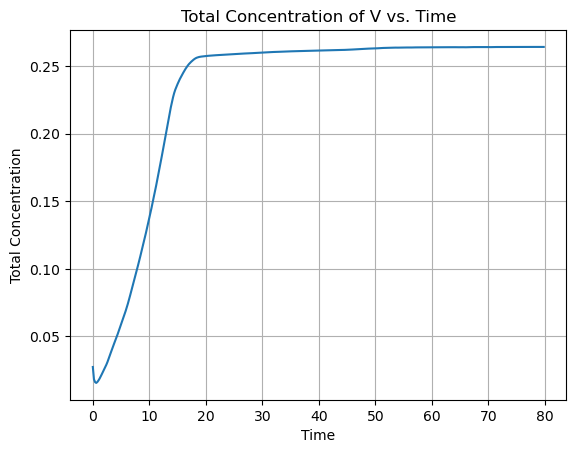

In [40]:
plt.figure()
plt.plot(total_time, total_V_concentration)
plt.xlabel("Time")
plt.ylabel("Total Concentration")
plt.title("Total Concentration of V vs. Time")
plt.grid(True)
plt.show()

(200,) (200, 200)


[]

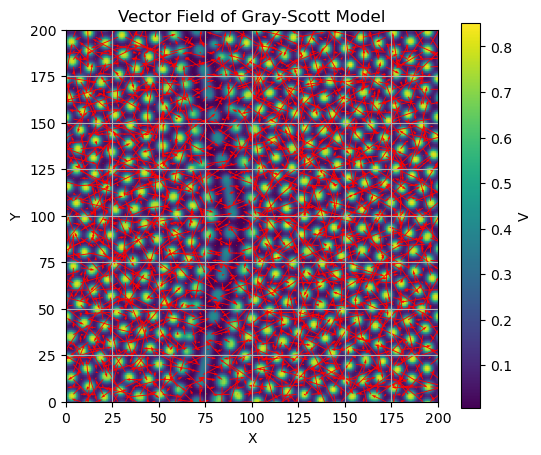

In [33]:
dVx = first_derivative(V, 1, dx)
dVy = first_derivative(V, 0, dx)

skip = 4
print(x.shape, dVx.shape)
# plt.figure()
plt.figure(figsize=(6,5))
plt.imshow(V, cmap='viridis')
plt.title('Gray Scott')
plt.colorbar(label='V')
plt.xlim(0,200)
plt.ylim(0,200)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Vector Field of Gray-Scott Model')
plt.grid()

plt.quiver(x[::skip], y[::skip], dVx[::skip,::skip], dVy[::skip, ::skip], color='red', scale=3)

plt.plot()

[]

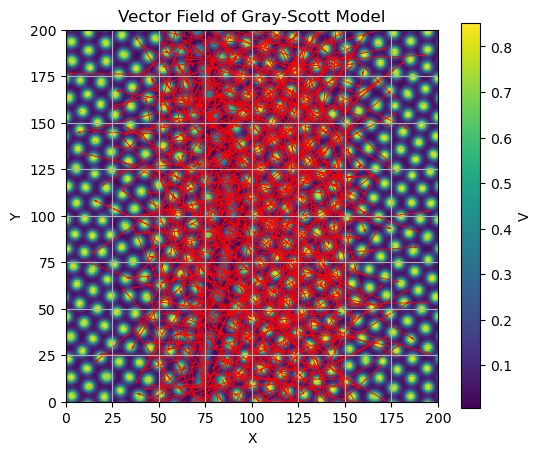

In [ ]:
# Create coordinate grids
x2, y2 = np.meshgrid(np.arange(N), np.arange(N))


''' OLD LOGIC'''
#Define masks
mask1 = y2 < (slope*x)
mask2 = y2 > (slope*x-300)
mask3 = y2 > (-slope * x + 200)
mask4 = y2 < (-slope * x +500)
mask5 = y2 > 100 ####must change because that was for old values

'''NEW LOGIC'''
#just need to change mask 1
# mask1 = y < slope * x - width * N/2
# mask2 = y > slope * x - 3 * N
# mask3 = y > -slope * x + t * N/2
# mask4 = y < -slope + 2 * N


'''MASKING'''

final_mask = (mask3 & mask4 & mask5) | (mask1 & mask2 & ~mask5) #Orginal mask and should be used. 

# final_mask = mask1 & mask2 & ~mask5


'''CALCULATIONS'''
dVx2 =final_mask * dVx
dVy2= final_mask * dVy

skip = 4
# Downsample both coordinate grids and vector components consistently
x_ds = x2[::skip, ::skip]
y_ds = y2[::skip, ::skip]
dVx_ds = dVx2[::skip, ::skip]
dVy_ds = dVy2[::skip, ::skip]

plt.figure(figsize=(6,5))
plt.imshow(V, cmap='viridis')
plt.colorbar(label='V')
plt.xlim(0, 200)
plt.ylim(0, 200)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Vector Field of Gray-Scott Model')
plt.grid()

# Overlay vector field
plt.quiver(x_ds, y_ds, dVx_ds, dVy_ds, color='red', scale=1)

plt.plot()













Rank 1: Bin center = 1.8005, Frequency = 1073
Rank 2: Bin center = 178.1999, Frequency = 1071
Rank 3: Bin center = 174.5999, Frequency = 979
90.15571607252681
53.544240695690235


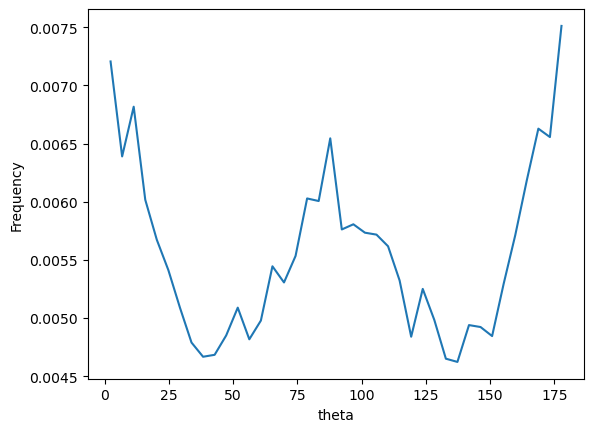

In [35]:
# V[V<0.1] = 0
# V[V>0.3] = 0

theta = np.arctan2(dVy, dVx) #produces values from -pi to pi
#so if I take all the values that are -pi + theta, then add pi, I will get theta. So all the values that will be -pi + theta should be less than 0/ 

theta[theta < 0] += np.pi #explain to Saaransh and see if that makes sense

theta = (theta * 180)/np.pi

# Histogram without plotting
counts, bin_edges = np.histogram(theta, bins=50)

# Sort counts in descending order and get top 3 indices
top_indices = np.argsort(counts)[::-1][:3]

# Get the bin centers and their counts
top_bins = [( (bin_edges[i] + bin_edges[i+1]) / 2, counts[i]) for i in top_indices]

# Print results
for rank, (center, freq) in enumerate(top_bins, start=1):
    print(f"Rank {rank}: Bin center = {center:.4f}, Frequency = {freq}")


bins = np.linspace(0, 180, 41)
hist, bin_edge = np.histogram(theta, bins, density=True)

bin_label = (bins[1:] + bins[:-1])/2
plt.plot(bin_label, hist)
# plt.hist(theta, bins=10,density=True)

print(np.mean(theta))
print(np.std(theta))

# plt.ylim(0,30)
plt.xlabel('theta')
plt.ylabel('Frequency')
plt.show()

